<a href="https://colab.research.google.com/github/suvyakthamedavarapu-hub/3SKILL-Projects/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Medavarapu Suvyaktha

Project - 1 (3SKILL)

Title: Wine Quality Prediction System

Project Objective:

To build a complete Machine Learning project using the Wine Quality dataset.

Step - 1: Load the Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving winequality (1).csv to winequality (1).csv


Step - 2: Import libraries and Read the Dataset

In [17]:
import pandas as pd

df = pd.read_csv('/content/winequality (1).csv')  # corrected file name
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Step - 3: Perform Basic Data Analysis

Using head(), info(), and describe().

In [18]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Step - 4: Check for missing values and analyze correlations between features and the quality column.

In [19]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


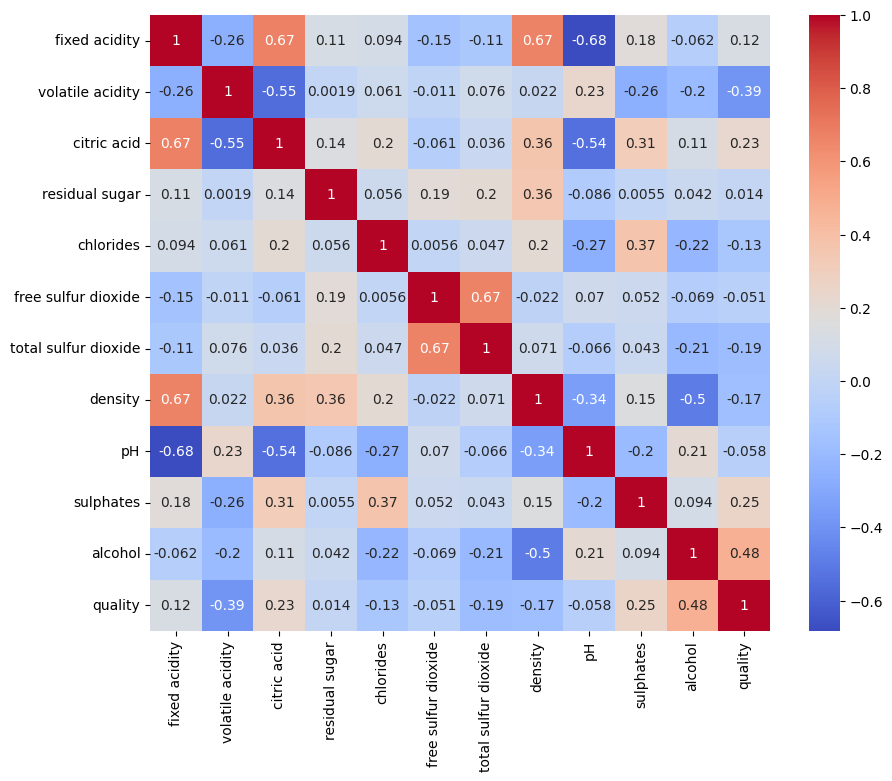

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Step - 5: Convert the quality column into a binary target called quality_label where quality

-- Greater than or equal to 7 is GOOD (1)

-- Less than 7 is BAD (0)

In [21]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

df['quality_label'].value_counts()

,count
quality_label,
0,1382
1,217


Step - 6:  Separate features and target

In [22]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

Step - 7: Perform train-test split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Step - 8: Train a Logistic Regression model without scaling and evaluate it using accuracy,

 precision, recall, F1-score, and confusion matrix.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.859375
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       273
           1       0.55      0.23      0.33        47

    accuracy                           0.86       320
   macro avg       0.72      0.60      0.62       320
weighted avg       0.83      0.86      0.83       320

[[264   9]
 [ 36  11]]


Confusion Matrix:
[[264   9]
 [ 36  11]]


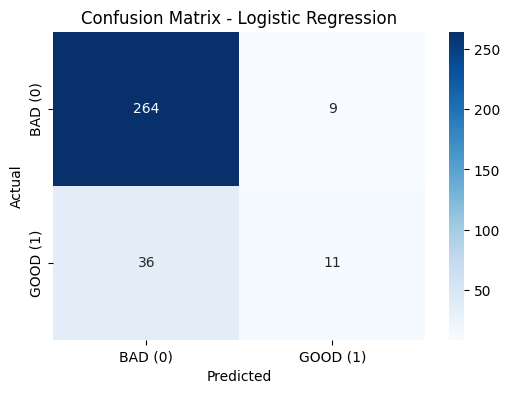

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test and y_pred are already defined from your Logistic Regression step
cm = confusion_matrix(y_test, y_pred)

# Print the raw matrix
print("Confusion Matrix:")
print(cm)

# Optional: Visualize it for a better presentation
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['BAD (0)', 'GOOD (1)'], yticklabels=['BAD (0)', 'GOOD (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Step - 9: Apply StandardScaler

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step - 10: Train the model again on scaled data, and compare results before and after scaling

In [27]:
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.865625
              precision    recall  f1-score   support

           0       0.89      0.97      0.92       273
           1       0.59      0.28      0.38        47

    accuracy                           0.87       320
   macro avg       0.74      0.62      0.65       320
weighted avg       0.84      0.87      0.84       320



Step - 11: Compare three models -> Logistic Regression, KNN, and Decision Tree

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

for name, m in models.items():
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    print(f"{name} Accuracy:", accuracy_score(y_test, pred))

Logistic Accuracy: 0.865625
KNN Accuracy: 0.88125
Decision Tree Accuracy: 0.89375


After Comparision the best model is Decision Tree.

Step - 12: Hyperparameter Tuning GridSearchCV on the best model and evaluate it again.

In [29]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 3, 'min_samples_split': 2}


Step - 13: Perform feature importance analysis to understand which features affect.

<Axes: >

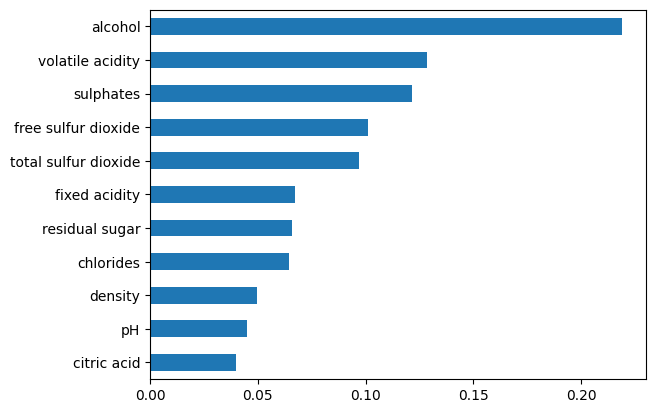

In [30]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

Conclusion:

This project analyzes the Wine Quality dataset to classify wines as GOOD or BAD based on physicochemical properties.

After preprocessing and converting the target variable into a binary label, multiple models including Logistic Regression, KNN, and Decision Tree were trained and evaluated.

It was observed that scaling improved the performance of models like Logistic Regression and KNN.

Among all models, the best performance was achieved by Decision Tree, based on accuracy and evaluation metrics.